# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [ ]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [ ]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
features= np.loadtxt("/content/RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("/content/RRLyrae_labels_small.txt", delimiter=',')

In [ ]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [ ]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483 entries, 0 to 2482
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   u-g       2483 non-null   float64
 1   g-r       2483 non-null   float64
 2   r-i       2483 non-null   float64
 3   i-z       2483 non-null   float64
 4   RR_Lyrae  2483 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 97.1 KB
None
               u-g          g-r          r-i          i-z     RR_Lyrae
count  2483.000000  2483.000000  2483.000000  2483.000000  2483.000000
mean      0.284691     0.983930     0.103497     0.053991     0.194523
std       0.106890     0.123618     0.056978     0.061693     0.395913
min      -0.141000     0.701000    -0.145000    -0.147000     0.000000
25%       0.249500     0.893000     0.077000     0.013000     0.000000
50%       0.319000     0.971000     0.120000     0.047000     0.000000
75%       0.362000     1.089000     0.141000     0.084000     0.0000

### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

1. Este es un problema de clasificación, porque queremos asignarle a una estrella una categoría.

2. Es un problema binario.

3. La variable objetivo (RR_Lyrae) indica si una estrella pertenece o no al tipo RR Lyrae.

4. Las clases están desbalanceadas.

5. Porque al ser clases desbalanceadas el accuracy se considera poco fiable, por lo que se deberá recurrir a otras métricas.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

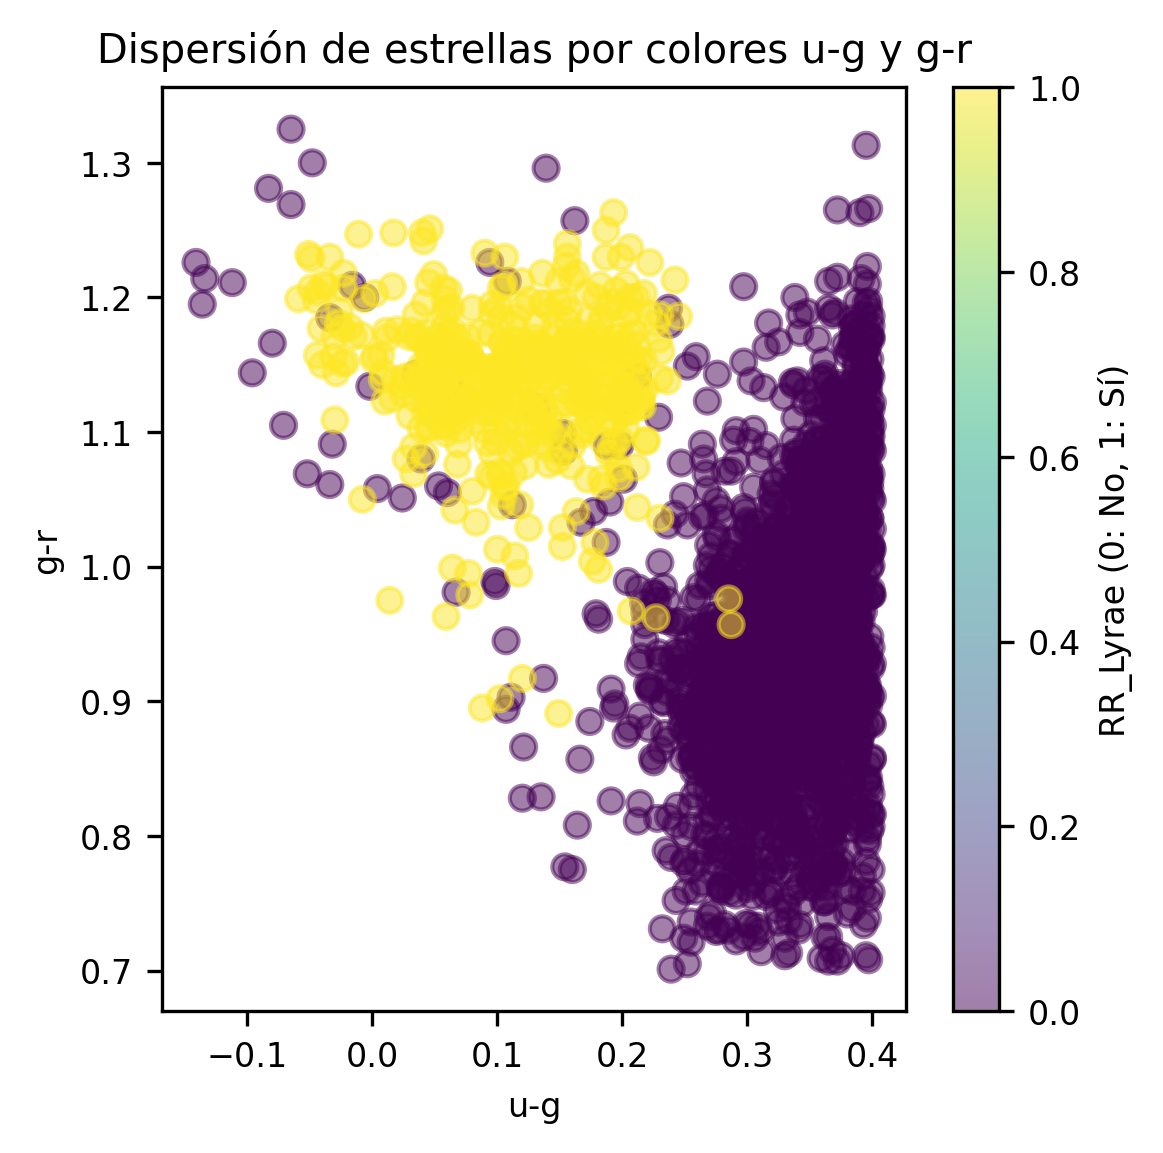

In [ ]:
#complete la celda
plt.figure(figsize=(4,4))

sc=plt.scatter(df['u-g'], df['g-r'], c=df['RR_Lyrae'], cmap='viridis', alpha=0.5)
plt.xlabel('u-g')
plt.ylabel('g-r')
plt.title('Dispersión de estrellas por colores u-g y g-r')
plt.colorbar(sc, label='RR_Lyrae (0: No, 1: Sí)')
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

1. Sí, se observan ciertas regiones donde las clases muestran separación parcial, aunque existe algo de superposición.

2. Sí, a simple vista, un árbol de decisión debería funcionar razonablemente bien. Aunque es probable que no sea perfecto debido a la superposición.

#### Separe los datos en entrenamiento y prueba

In [ ]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [ ]:
#complete la celda
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?

Podría ocurrir que una clase quede subrepresentada en train o test.

2. ¿Por qué eso podría afectar la evaluación del modelo?

Porque el modelo aprendería mal esa clase o la evaluación no reflejaría el desempeño real.

3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

Usar muestreo estratificado (stratify=y) para mantener la proporción de clases.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [ ]:
model_tree = DecisionTreeClassifier(random_state=42)

#entrene el modelo y genere las predicciones
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

#### Visualicemos el árbol

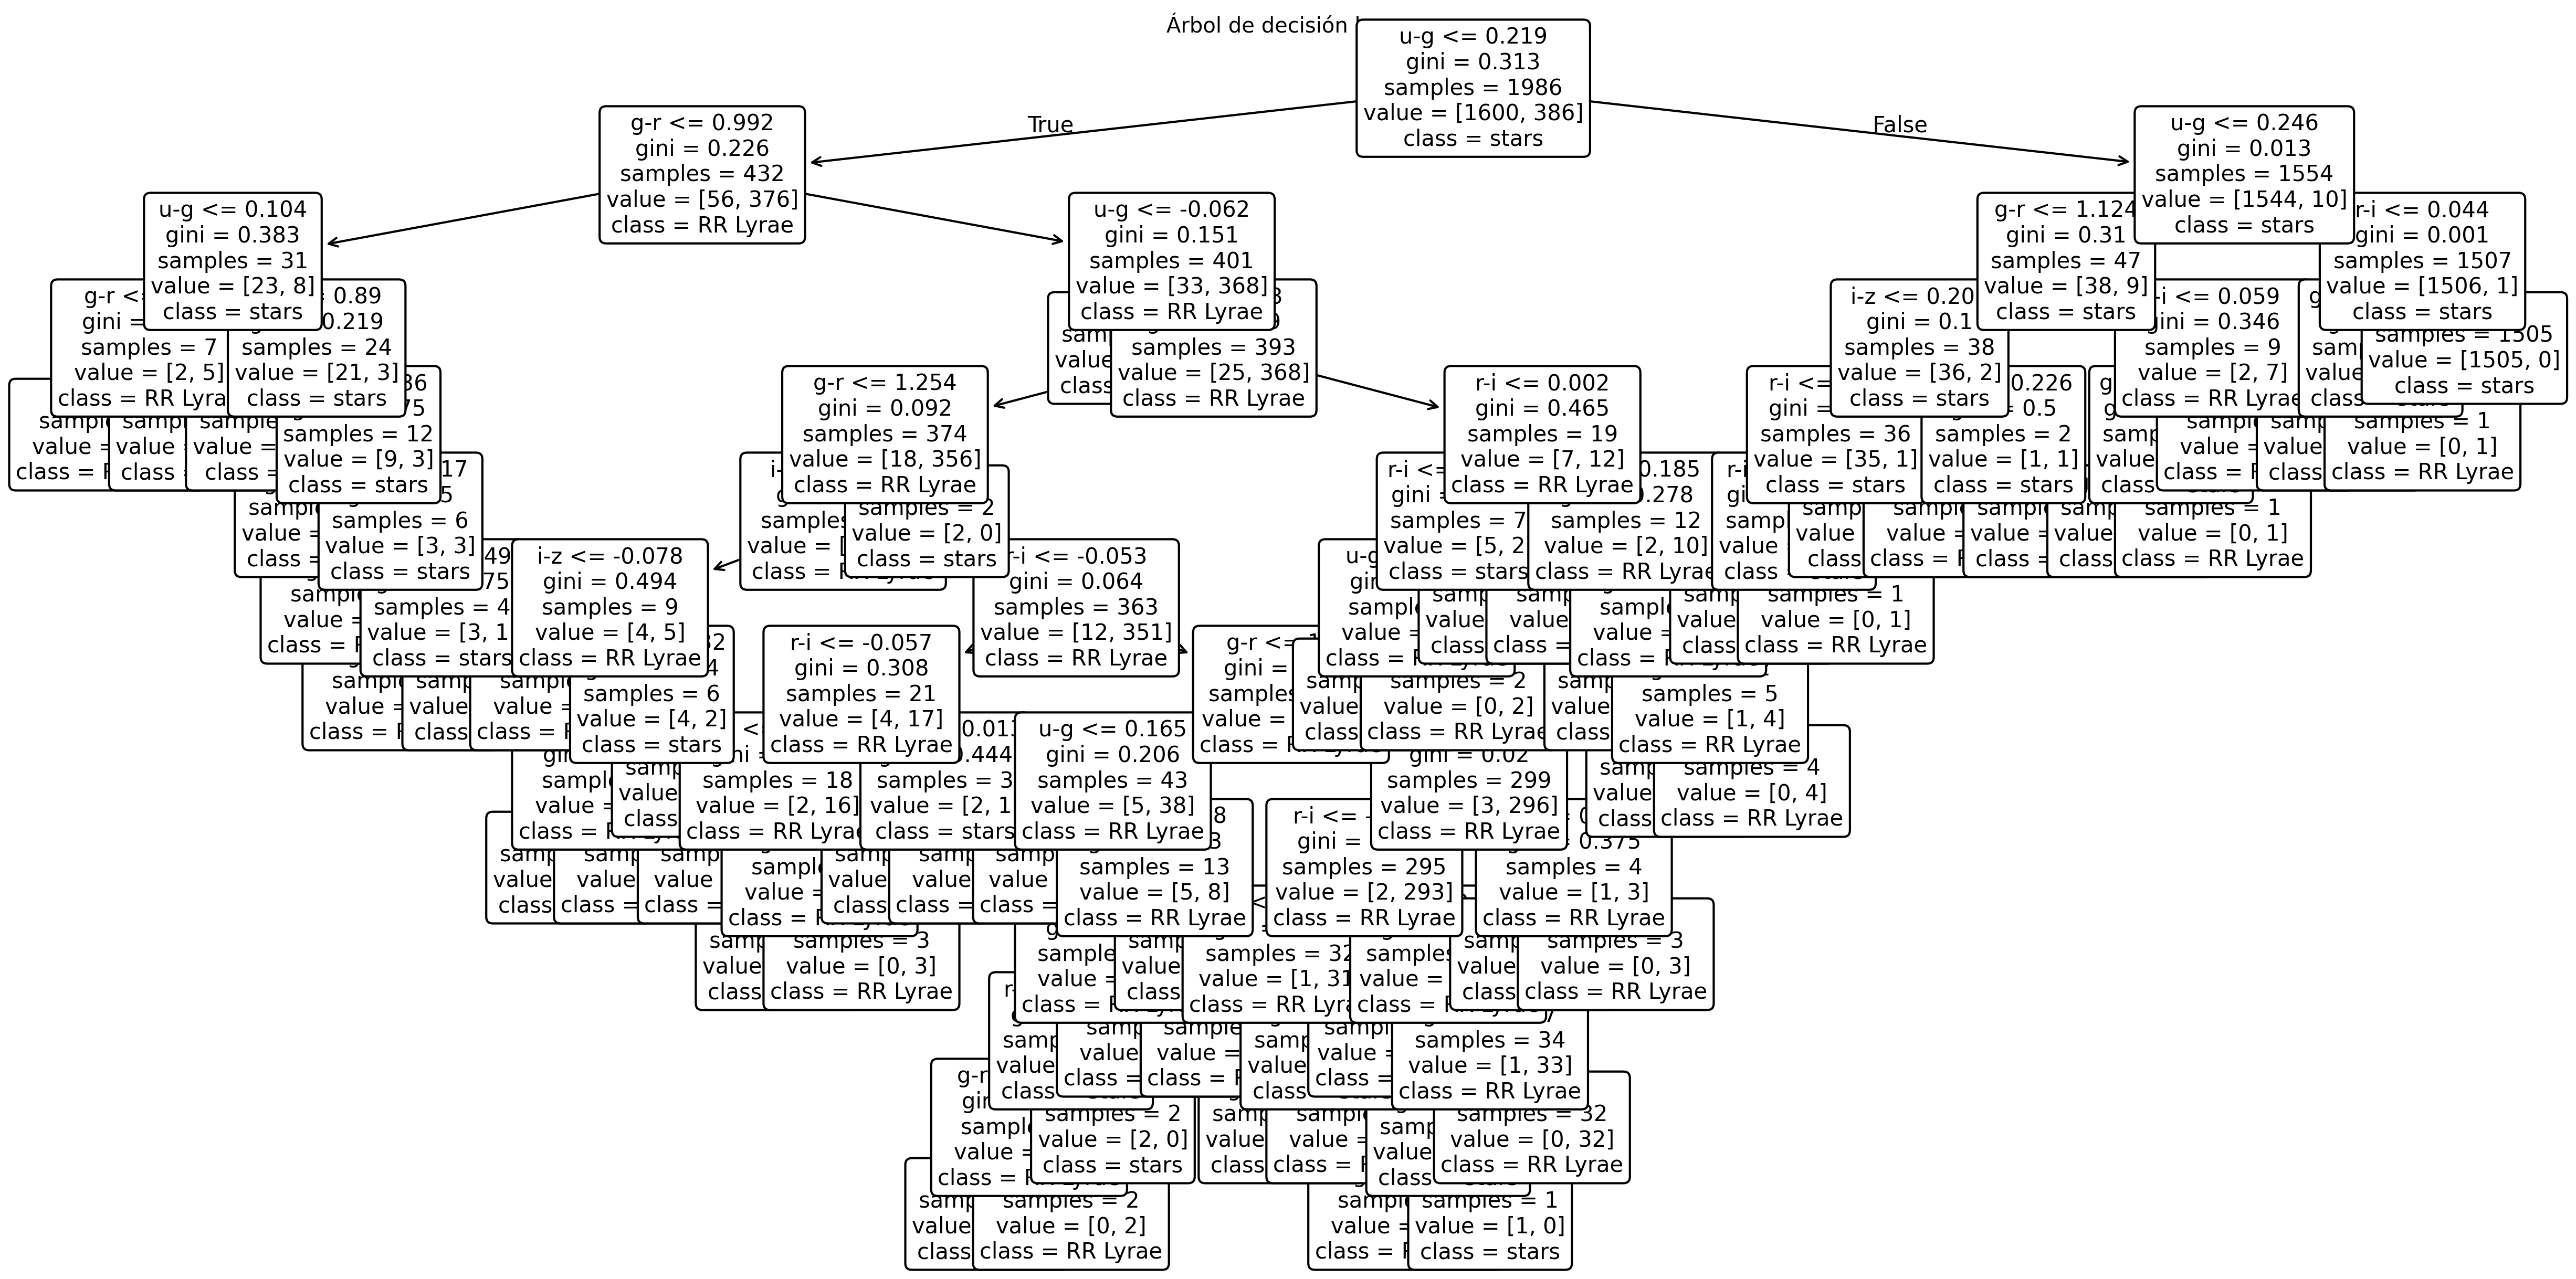

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

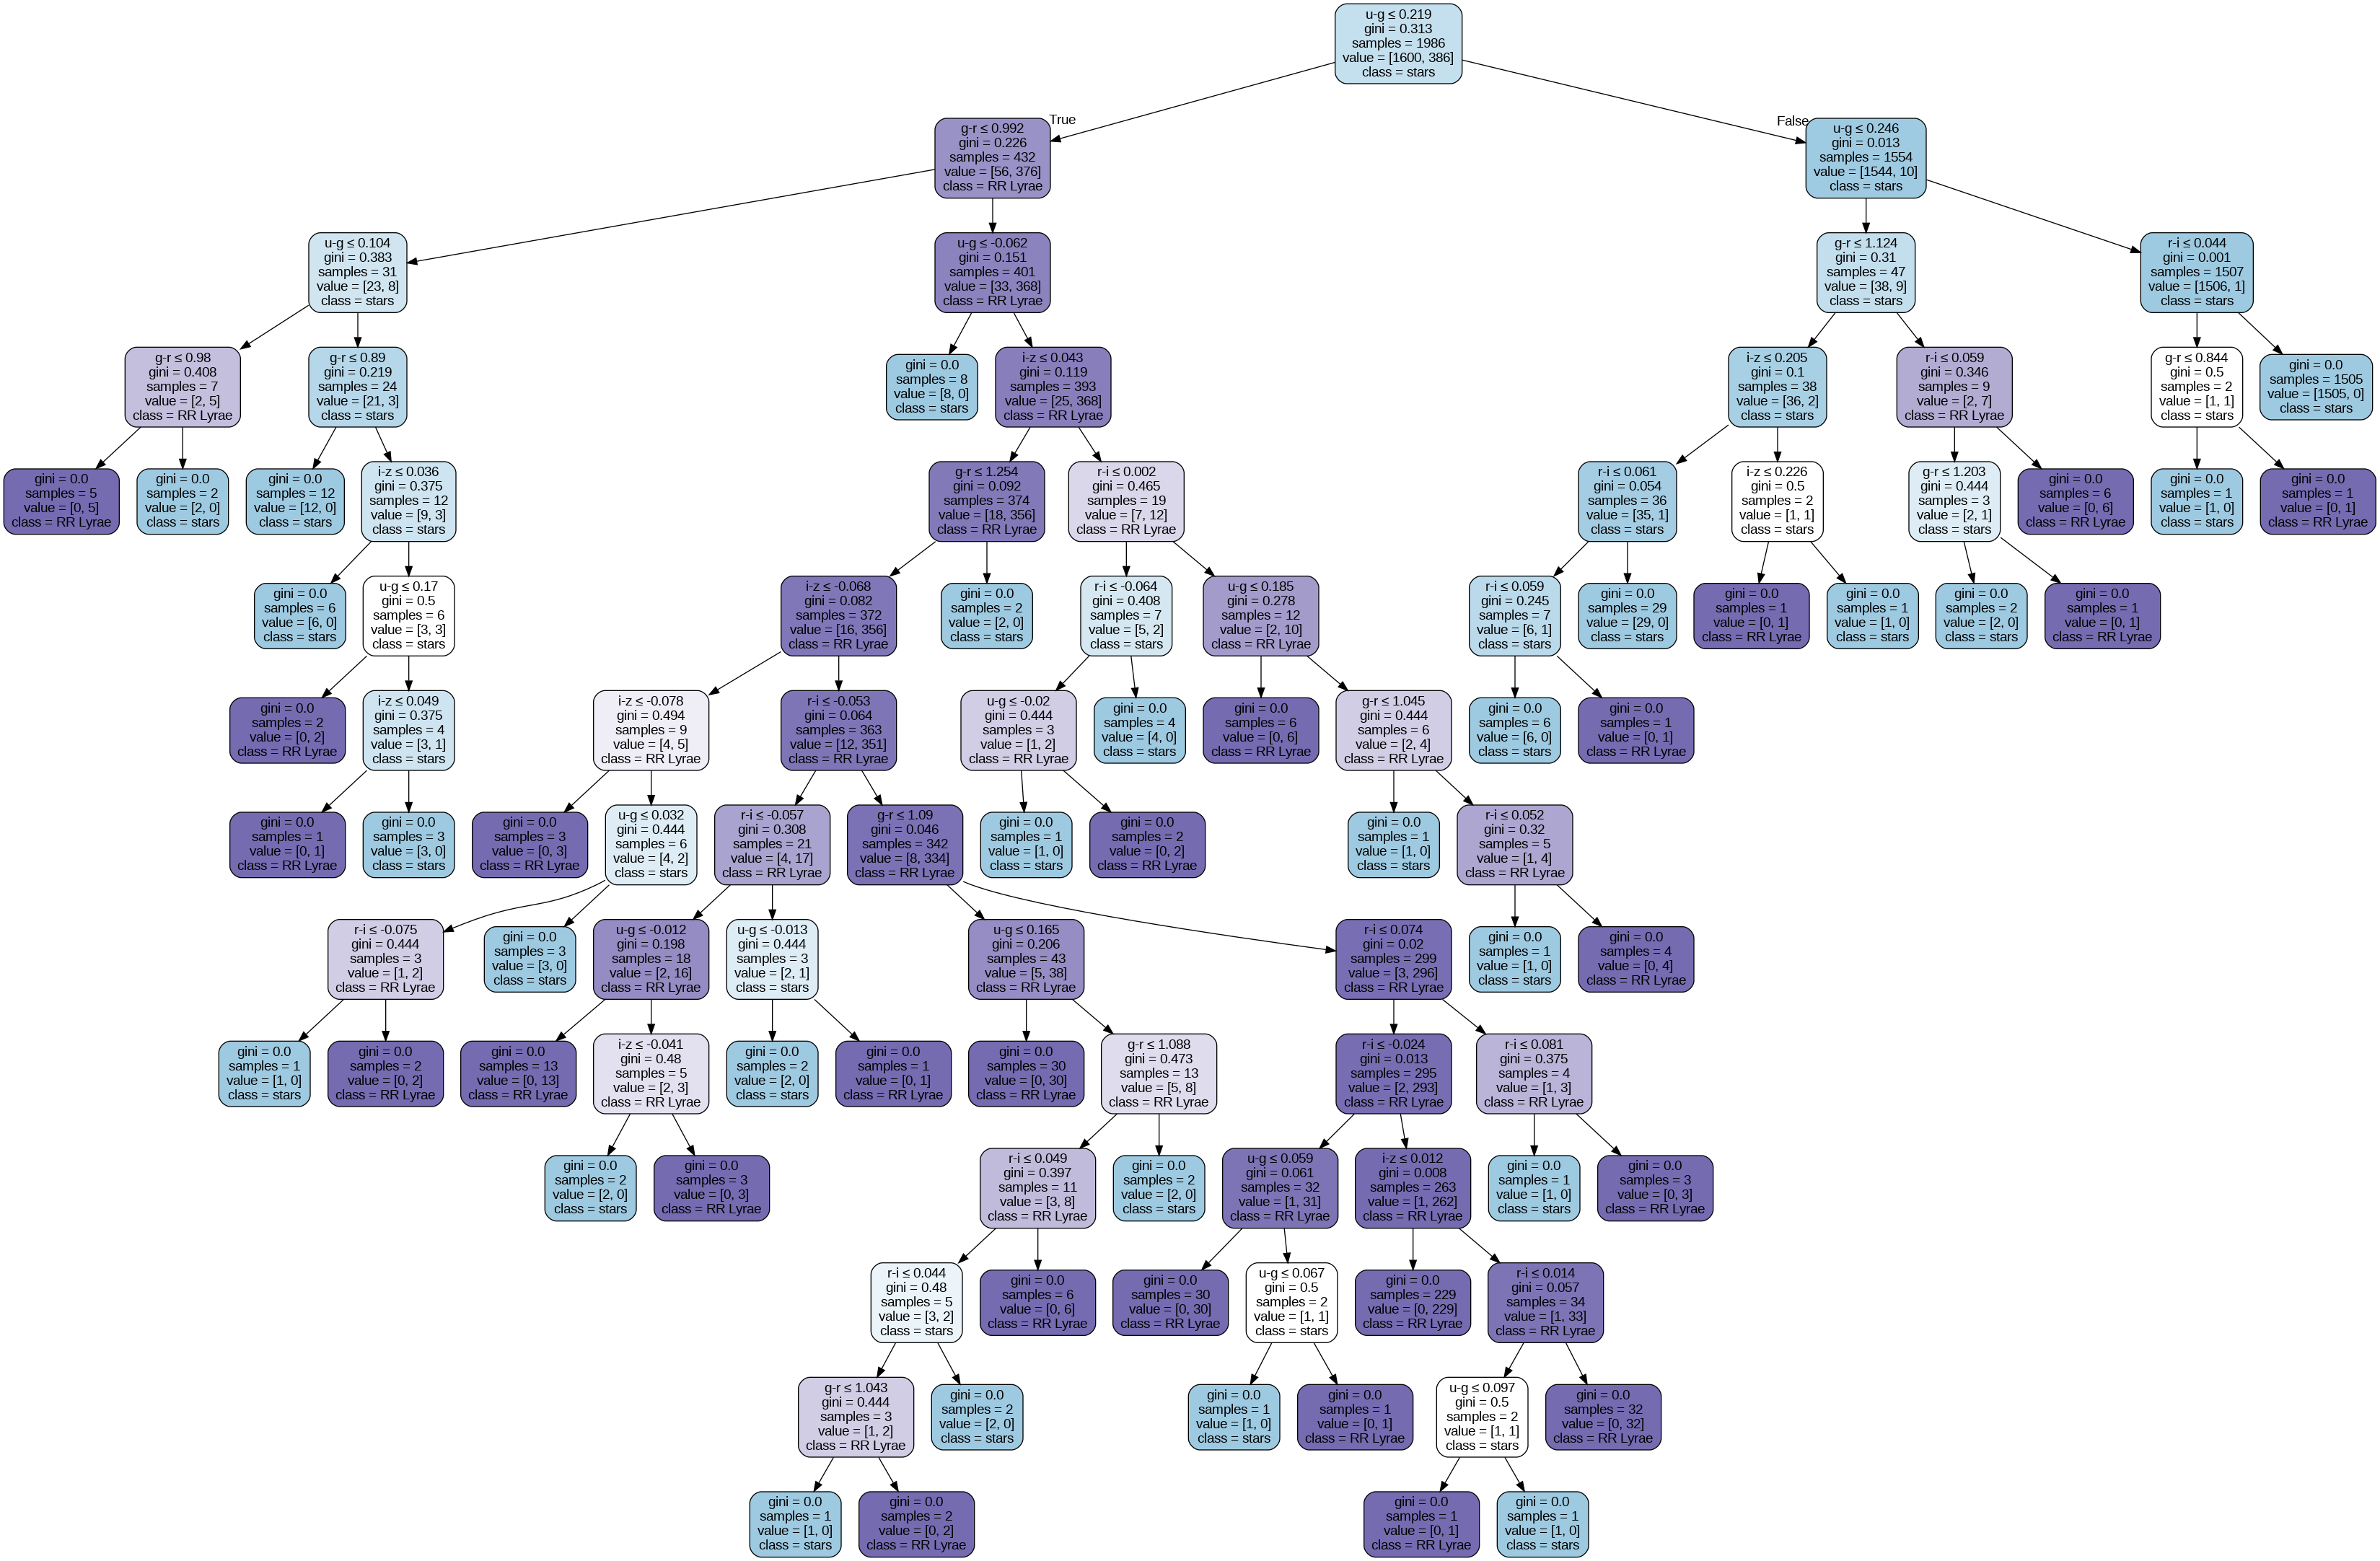

In [ ]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

1. Es un árbol complejo
2. Puede producir sobreajuste, aprendiendo ruido del entrenamiento y generalizando peor.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [ ]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9798792756539235


#### Otras métricas

In [ ]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.9306930693069307
Recall   : 0.9690721649484536
F1-score : 0.9494949494949495


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[393,   7],
       [  3,  94]])

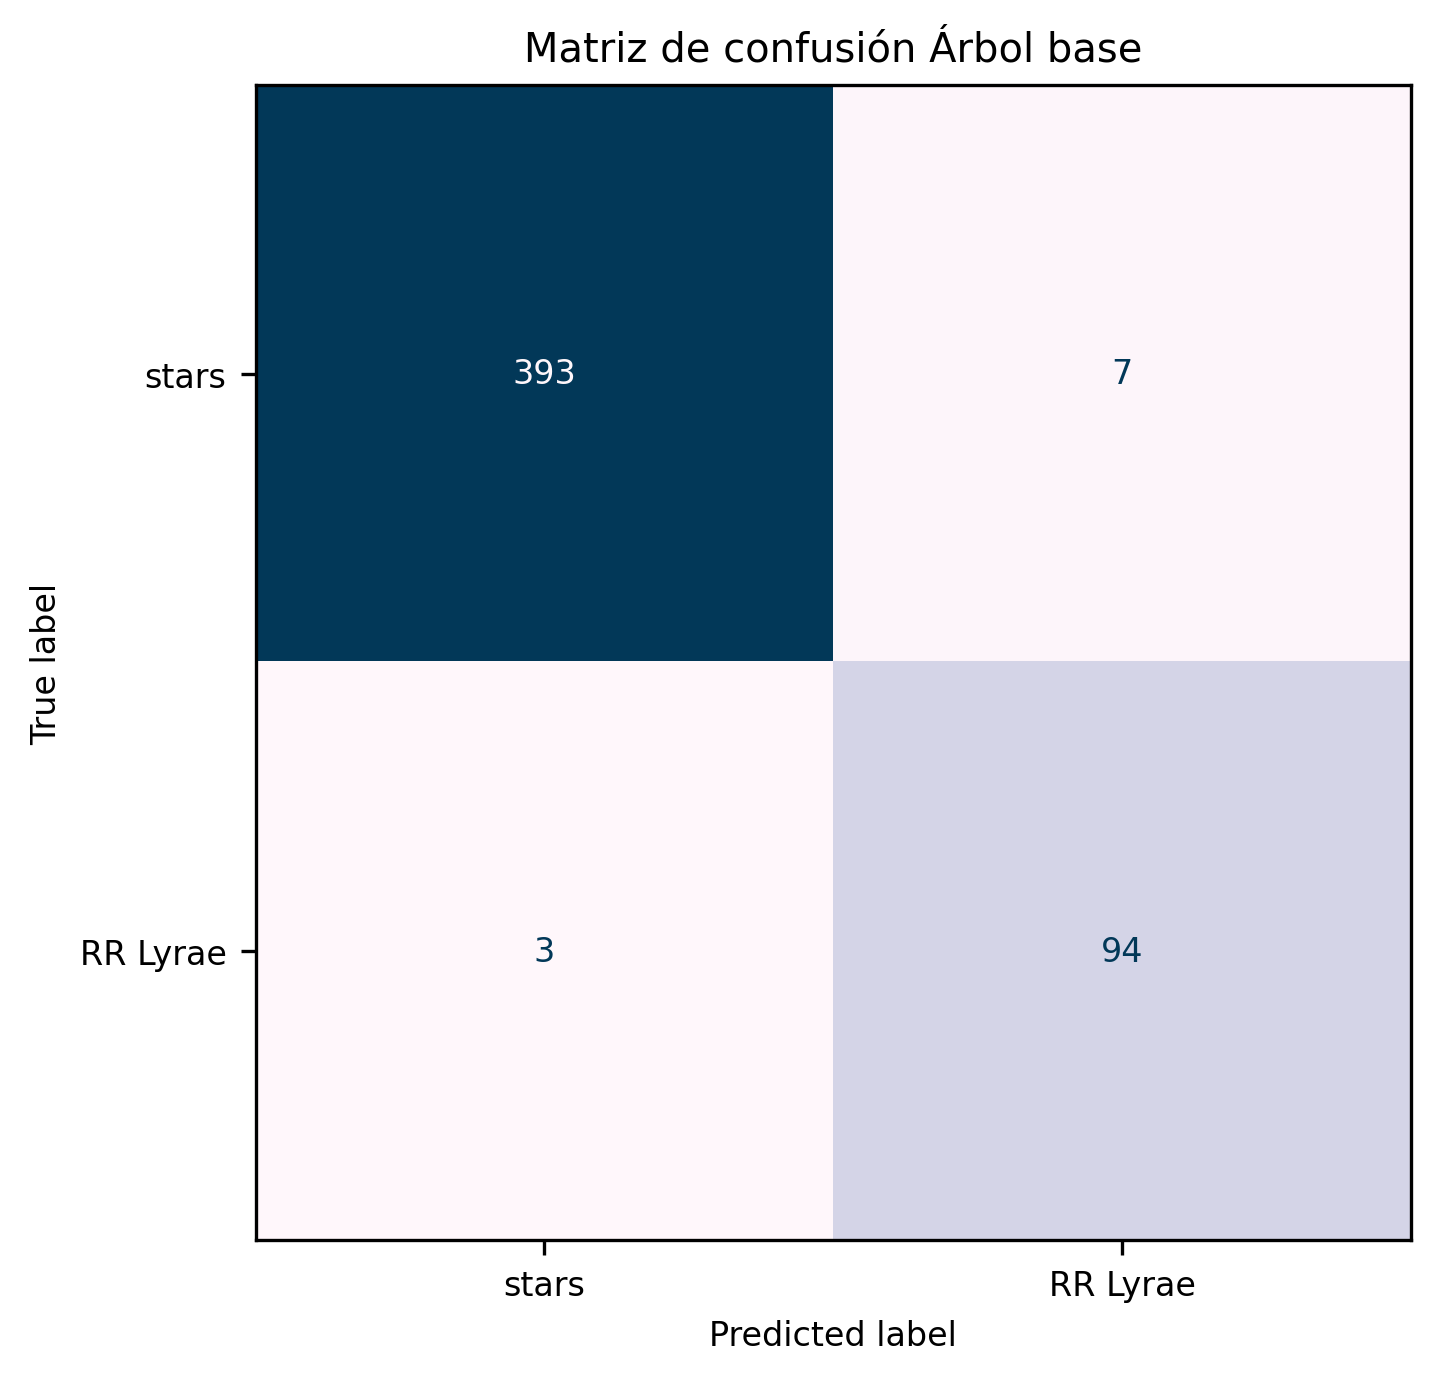

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



1.   Verdaderos Positivos (TP): 94

     Verdaderos Negativos (TN): 393

     Falsos Positivos (FP): 7

     Falsos Negativos (FN): 3

2. Accuracy: 0.980

   Precision: 0.931

   Recall: 0.969

   F1-score: 0.949


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

1.  

*   Un falso positivo sería una estrella normal clasificada erróneamente como RR Lyrae.

*   Un falso negativo sería una RR Lyrae real clasificada erróneamente como estrella normal.

2. Preocuparían más los falsos negativos, porque se nos escaparían estrellas importantes.

3. Preocupan más los falsos positivos, porque contaminarían la muestra.


#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [ ]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [ ]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7d0c317846a0>

In [ ]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [ ]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [ ]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [ ]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [ ]:
scores3

{'fit_time': array([0.01006293, 0.00846004, 0.00953579, 0.010463  , 0.0099268 ]),
 'score_time': array([0.00328732, 0.00357866, 0.00336123, 0.00369191, 0.00654292]),
 'test_score': array([0.97987928, 0.96780684, 0.96579477, 0.97983871, 0.96370968])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [ ]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.784 0.379


In [ ]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.010


In [ ]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.007


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [ ]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [ ]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [ ]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [ ]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.913 1.000
0.921 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [ ]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [ ]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [ ]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [ ]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [ ]:
np.sum(y_cv2)

np.int64(485)

In [ ]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [ ]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [ ]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [ ]:
model = DecisionTreeClassifier(random_state = 5)

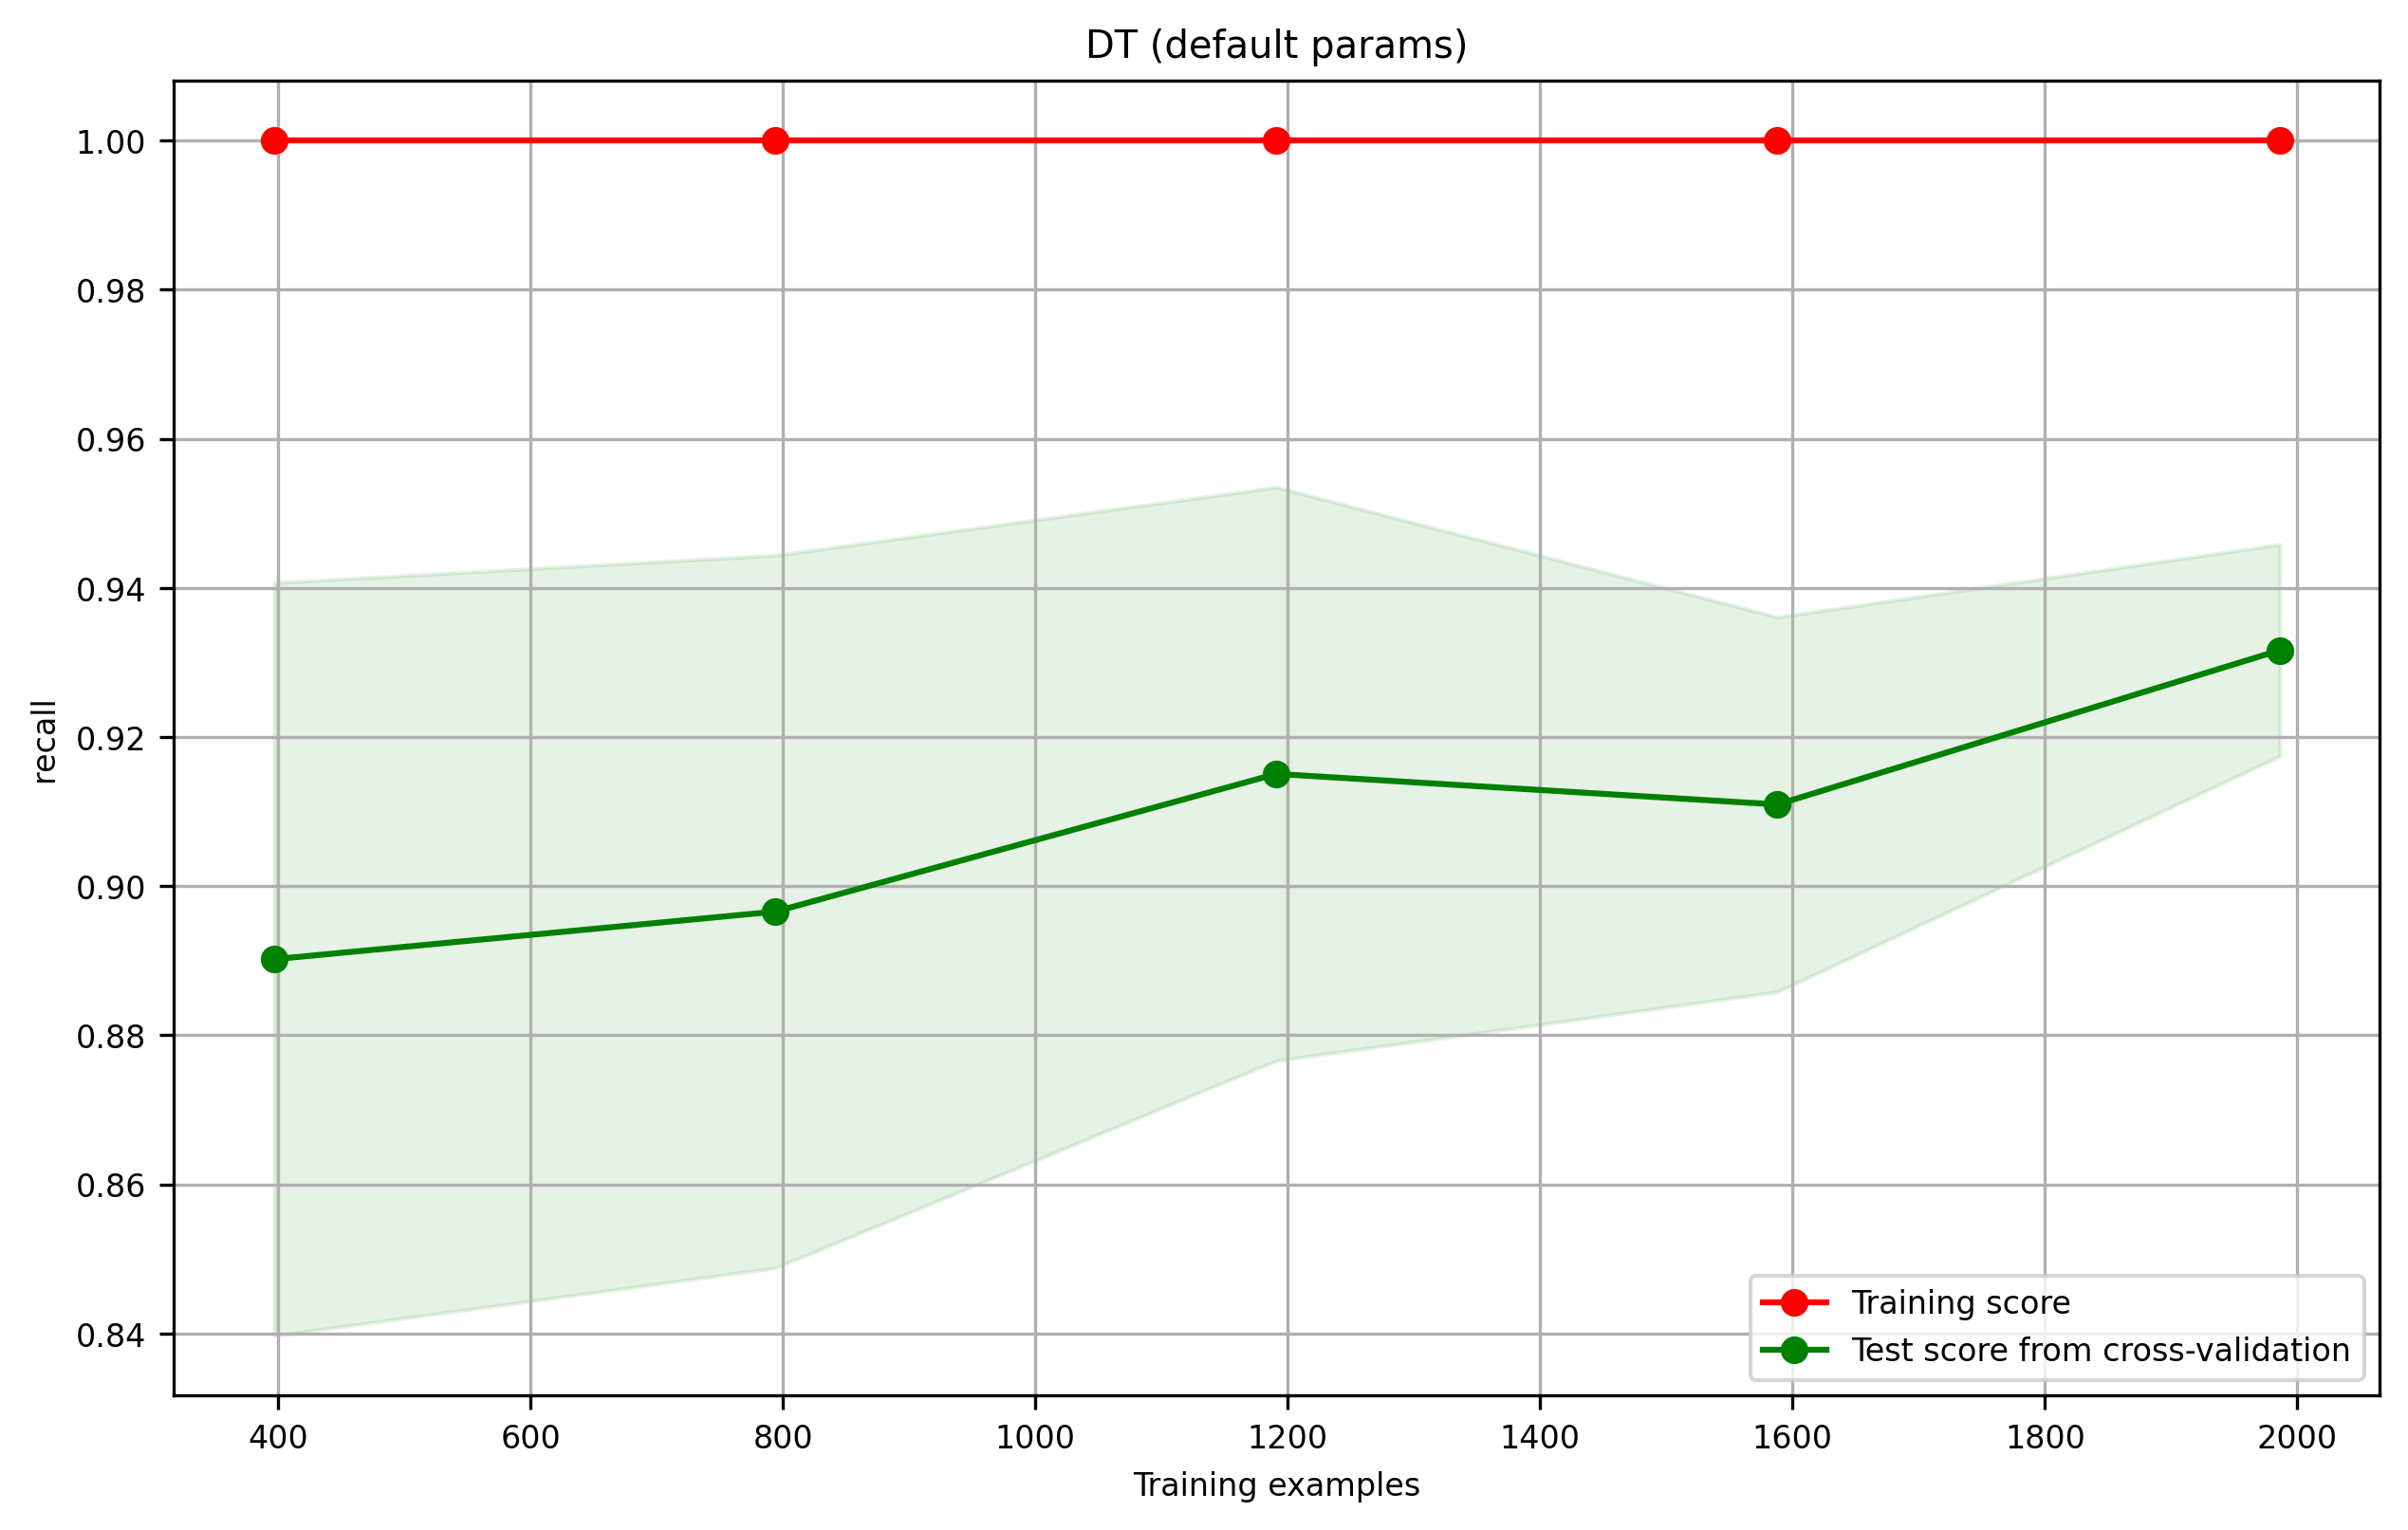

In [ ]:
plot_learning_curve(model_tree, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

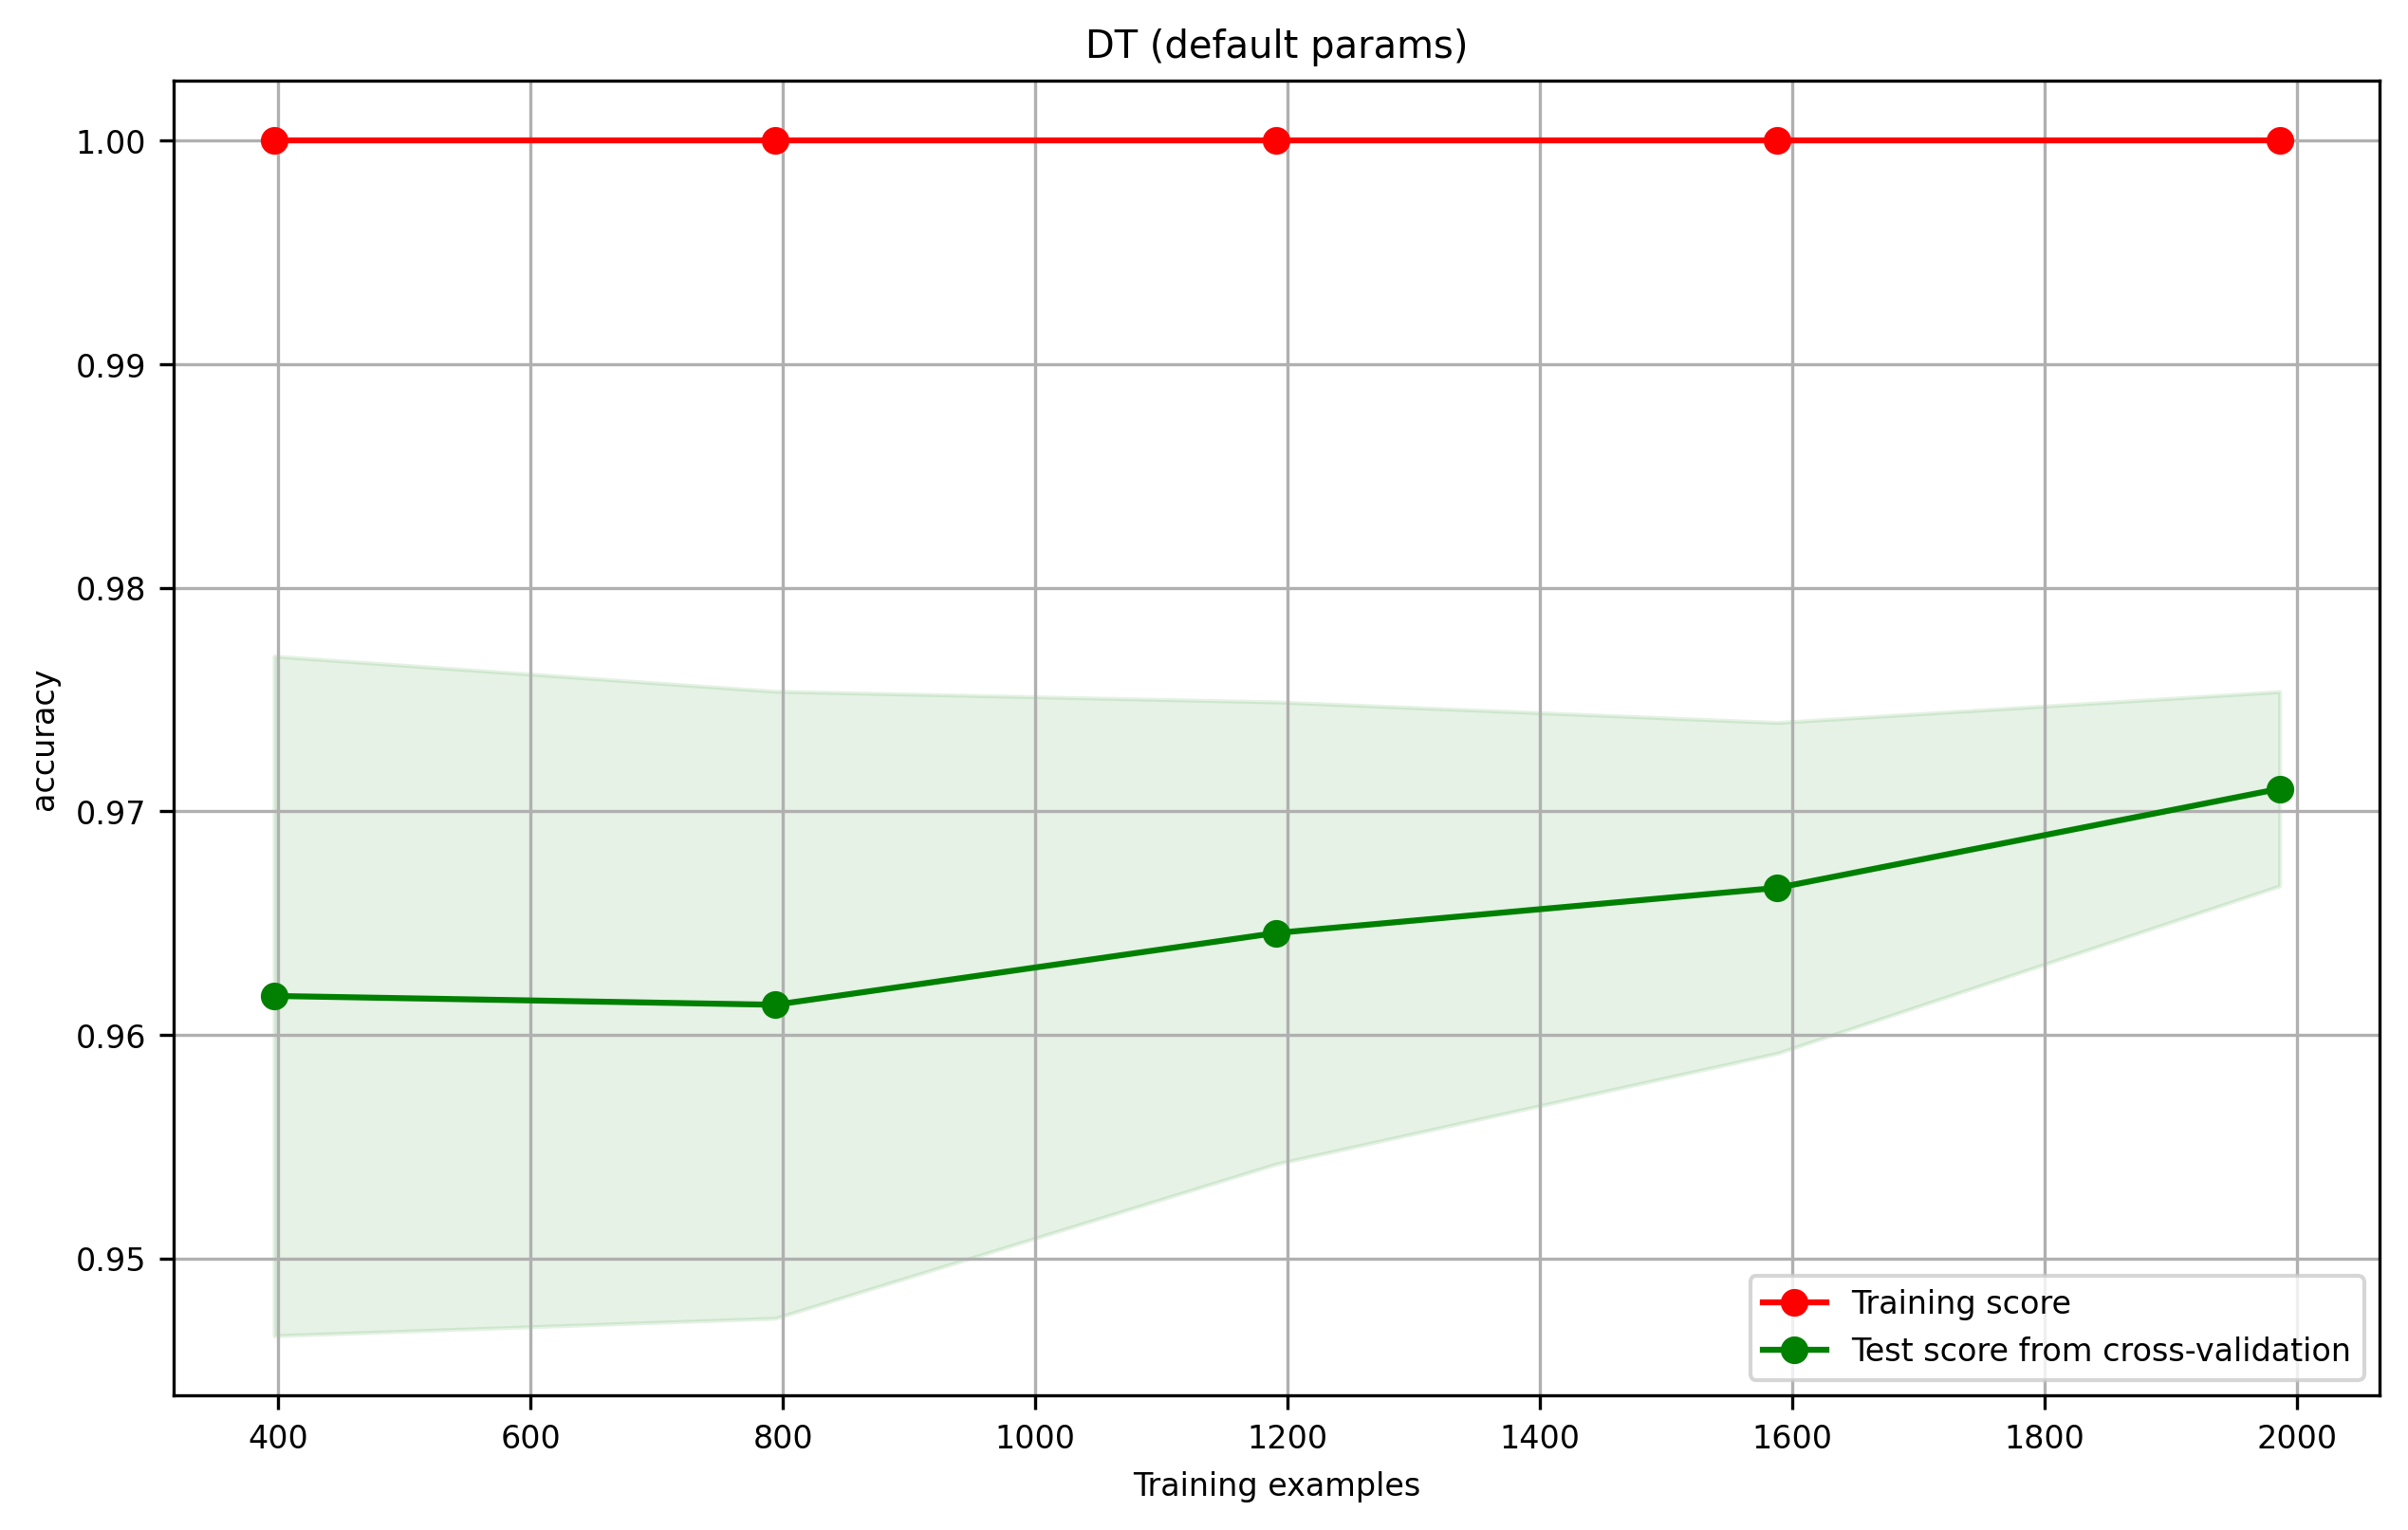

In [ ]:
plot_learning_curve(model_tree, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

1. Sí, existe y sugiere alta varianza.

2. Sí, suele mejorar gradualmente y estabilizarse.

3. Alta varianza, ya que el modelo muestra un desempeño considerablemente mejor en el conjunto de entrenamiento que en el de validación. Es decir, el modelo aprende muy bien los datos de entrenamiento, pero su desempeño disminuye en datos no vistos.

4. El árbol base aprende bien entrenamiento, pero pierde capacidad de generalización por exceso de complejidad.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [ ]:
model_tree_simple = DecisionTreeClassifier(max_depth=3, random_state=42)

print("Evaluando el árbol simple (max_depth=3):")

metrics_simple = cross_validate(model_tree_simple, X, y, cv=cv3,
                                  scoring=['accuracy', 'precision', 'recall', 'f1'],
                                  return_train_score=False)

print("\nArbol Simple (max_depth=3) - Test Scores:")
print(f"Accuracy: {metrics_simple['test_accuracy'].mean():.3f} (std: {metrics_simple['test_accuracy'].std():.3f})")
print(f"Precision: {metrics_simple['test_precision'].mean():.3f} (std: {metrics_simple['test_precision'].std():.3f})")
print(f"Recall: {metrics_simple['test_recall'].mean():.3f} (std: {metrics_simple['test_recall'].std():.3f})")
print(f"F1-score: {metrics_simple['test_f1'].mean():.3f} (std: {metrics_simple['test_f1'].std():.3f})")


Evaluando el árbol simple (max_depth=3):

Arbol Simple (max_depth=3) - Test Scores:
Accuracy: 0.977 (std: 0.008)
Precision: 0.925 (std: 0.023)
Recall: 0.961 (std: 0.024)
F1-score: 0.942 (std: 0.019)


In [ ]:
print("\nEvaluando el árbol base (sin restricciones de profundidad):")
metrics_base = cross_validate(model_tree, X, y, cv=cv3,
                              scoring=['accuracy', 'precision', 'recall', 'f1'],
                              return_train_score=False)

print("\nArbol Base - Test Scores:")
print(f"Accuracy: {metrics_base['test_accuracy'].mean():.3f} (std: {metrics_base['test_accuracy'].std():.3f})")
print(f"Precision: {metrics_base['test_precision'].mean():.3f} (std: {metrics_base['test_precision'].std():.3f})")
print(f"Recall: {metrics_base['test_recall'].mean():.3f} (std: {metrics_base['test_recall'].std():.3f})")
print(f"F1-score: {metrics_base['test_f1'].mean():.3f} (std: {metrics_base['test_f1'].std():.3f})")


Evaluando el árbol base (sin restricciones de profundidad):

Arbol Base - Test Scores:
Accuracy: 0.971 (std: 0.004)
Precision: 0.920 (std: 0.012)
Recall: 0.932 (std: 0.014)
F1-score: 0.926 (std: 0.011)


### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

1. Todas las métricas mostraron valores medios ligeramente superiores para el árbol más simple en comparación con el árbol base.

2. El árbol más simple mejoró la generalización. Los valores medios superiores en todas las métricas, especialmente en Recall y F1-score, indican que el modelo es más robusto y predice mejor en datos no vistos, implicando que el arbol evita el sobreajuste.

3. Al árbol base no poseer restricciones de profundidad probablemente el árbol se encontraba sobreajustando los datos de entrenamiento. Aquello le impidió generalizar de buena manera los nuevos datos.

4. No, se puede observar que el árbol simple presentó una generalización superior a comparación del árbol base.

5. Considero que las métricas más importantes entre ambos modelos serían el Recall y el F1-score. El Recall nos ayudó a minimizar los falsos negativos, implicando una menor perdida de estrellas RR Lyrae verdaderas y el F1-score nos dió el equilibrio entre la precisión y el recall, como el árbol simple obtuvo un F1_Score más alto hace al modelo deseable.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [ ]:
pipeline_knn_k5 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))])

# Evaluar el modelo kNN con k=5 usando validación cruzada estratificada
print("\nEvaluando kNN con k=5:")
metrics_knn_k5 = cross_validate(pipeline_knn_k5, X, y, cv=cv3,
                                  scoring=['accuracy', 'precision', 'recall', 'f1'],
                                  return_train_score=False)

print("kNN (k=5) - Test Scores:")
print(f"Accuracy: {metrics_knn_k5['test_accuracy'].mean():.3f} (std: {metrics_knn_k5['test_accuracy'].std():.3f})")
print(f"Precision: {metrics_knn_k5['test_precision'].mean():.3f} (std: {metrics_knn_k5['test_precision'].std():.3f})")
print(f"Recall: {metrics_knn_k5['test_recall'].mean():.3f} (std: {metrics_knn_k5['test_recall'].std():.3f})")
print(f"F1-score: {metrics_knn_k5['test_f1'].mean():.3f} (std: {metrics_knn_k5['test_f1'].std():.3f})")


Evaluando kNN con k=5:
kNN (k=5) - Test Scores:
Accuracy: 0.978 (std: 0.006)
Precision: 0.922 (std: 0.021)
Recall: 0.969 (std: 0.011)
F1-score: 0.945 (std: 0.015)


## Preguntas

1. El rendimiento de kNN similar al del árbol simple, incluso ligeramente superior para este problema. Por ejemplo, kNN tiene un Recall y un F1-score ligeramente mejores, lo que lo hace un poco más efectivo en la identificación de las estrellas RR Lyrae y mantiene un buen equilibrio entre precisión y recall.

2. Cuando k es muy pequeño, el modelo kNN se vuelve muy sensible al ruido en los datos de entrenamiento. Esto puede llevar a un sobreajuste, pero no generaliza bien a datos nuevos.

3. Cuando k es muy grande, el modelo kNN se basa en la mayoría de las clases dentro de un vecindario muy amplio. Esto puede llevar a un subajuste, donde el modelo es demasiado simple y no captura los patrones subyacentes de los datos.

4. Buscamos el valor de k que maximice el F1-score. Según nuestros resultados iniciales, k=5 ya muestra un muy buen F1-score. Si exploráramos otros valores de k, buscaríamos aquel que mantenga un F1-score alto y una desviación estándar baja.

5. Una ventaja significativa de kNN es que no asume una forma específica para la frontera de decisión. Por lo tanto, kNN puede crear fronteras de decisión complejas y no lineales que se adaptan bien a la forma intrínseca de los datos, lo que le permite capturar relaciones más intrincadas entre las características y las clases cuando la separación no es de tipo rectangular.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.

In [ ]:
# Replace 'your_file.txt' with the actual path to your text file
try:
    with open('/content/RRLyrae_features_small.txt', 'r') as file:
        content = file.read()
        print(content[:500]) # Print the first 500 characters of the file
except FileNotFoundError:
    print("Error: The file was not found. Please check the path.")

0.3110,0.7140,0.0930,0.2040
0.3320,0.9650,0.1220,0.0320
0.3940,1.0190,0.1470,0.0960
0.2850,0.8650,0.1200,0.0390
0.3860,0.9770,0.1810,0.0800
0.3390,0.8350,0.1610,0.0280
0.2740,0.9020,0.1280,0.0200
0.3700,0.8930,0.1530,0.0820
0.3970,1.1190,0.1420,0.0540
0.2470,1.0770,0.0680,0.0180
0.3880,0.8620,0.1520,0.1380
0.3430,0.9180,0.0890,0.1760
0.2720,0.8150,0.0820,0.0820
0.3260,0.8940,0.0820,0.1290
0.3220,0.9470,0.1530,0.0600
0.3680,0.8000,0.1190,0.1770
0.3920,0.8190,0.1600,0.1270
0.3550,1.0360,0.1400,0.0
